In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split



In [3]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
data.drop(columns=['API_UserName','observations','day','month'], inplace=True)
# Ensure the 'date' column is in datetime format
data['date'] = pd.to_datetime(data['date'])
#data = data[data['indicator'] == '46.246.8.21']
data.tail(10)

,date,indicator,dayofweek,is_weekend,seen
22904,2025-04-24,176.113.74.89,3,False,0
22905,2025-04-24,190.92.174.48,3,False,0
22906,2025-04-24,190.92.174.92,3,False,0
22907,2025-04-24,20.48.204.4,3,False,0
22908,2025-04-24,47.237.115.193,3,False,0
22909,2025-04-24,107.180.119.251,3,False,0
22910,2025-04-24,190.92.174.36,3,False,0
22911,2025-04-24,192.124.249.112,3,False,0
22912,2025-04-24,66.132.159.247,3,False,0
22913,2025-04-24,213.229.107.11,3,False,0


In [4]:
# Utility function for smoothing values
def smooth(values, weight=0.8):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed

# Example usage:
# modelData['smoothed_days_since_last_seen'] = smooth(modelData['days_since_last_seen'].values, weight=0.8)

In [5]:
# Ensure the data is sorted by 'indicator' and 'date'
data = data.sort_values(['indicator', 'date']).reset_index(drop=True)

# Initialize the 'days_since_last_seen' column with default values
data['days_since_last_seen'] = np.nan

# Calculate days since 'seen' was last equal to 1 for each indicator
for indicator, group in data.groupby('indicator'):
    # Filter rows where 'seen' is 1
    seen_dates = group[group['seen'] == 1]['date']
    
    # Calculate the difference in days for each row
    group['days_since_last_seen'] = group['date'].apply(
        lambda x: (x - seen_dates[seen_dates < x].max()).days if not seen_dates[seen_dates < x].empty else np.nan
    )
    
    # Update the main DataFrame
    data.loc[group.index, 'days_since_last_seen'] = group['days_since_last_seen']

# Fill NaN values with 0 (e.g., for the first occurrence of each indicator)
data['days_since_last_seen'] = data['days_since_last_seen'].fillna(0).astype(int)

# Add exponentially weighted mean of past activity (ewm_seen)
data['ewm_seen'] = data.groupby('indicator')['seen'].apply(lambda x: x.ewm(span=3, adjust=False).mean()).reset_index(drop=True)

# Add rolling count of 'seen == 1' in the last 3 days (seen_count_last_3)
data['seen_count_last_3'] = data.groupby('indicator')['seen'].apply(lambda x: x.rolling(window=3, min_periods=1).sum()).reset_index(drop=True)
# Add rolling averages for 'seen' over different windows
data['rolling_mean_7'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
data['rolling_mean_30'] = data.groupby('indicator')['seen'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())

# Add longer exponential moving averages
data['ewm_seen_long'] = data.groupby('indicator')['seen'].transform(lambda x: x.ewm(span=10, adjust=False).mean())

# Total seen over time
total_seen = data.groupby('indicator')['seen'].transform('sum')

# Use total_seen for activity_score
data['activity_score'] = total_seen

# Normalize activity_score
data['activity_score_normalized'] = (data['activity_score'] - data['activity_score'].min()) / (
    data['activity_score'].max() - data['activity_score'].min()
)

# Categorize into tiers
data['activity_tier'] = pd.qcut(total_seen, q=3, labels=[0, 1, 2])  # 0 = low, 1 = medium, 2 = high
# Smooth the 'days_since_last_seen' column
data['smoothed_days_since_last_seen'] = smooth(data['days_since_last_seen'].values, weight=0.8)



In [6]:
data['date'] = pd.to_datetime(data['date'])
test_data = data[data['date'] == '2025-04-24 00:00:00']
#cutoff data 7 days ago and on
cutoff_date = datetime.now() - timedelta(days=7)
modelData = data[data['date'] <= cutoff_date]
modelData = modelData.sort_values(['indicator', 'date']).reset_index(drop=True)

In [7]:
modelData[modelData['indicator'] == '102.129.153.43']

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_30,ewm_seen_long,activity_score,activity_score_normalized,activity_tier,smoothed_days_since_last_seen
107,2025-01-01,102.129.153.43,2,False,0,0,0.000000e+00,0.0,0.0,0.0,0.000000,2,0.010309,0,18.440691
108,2025-01-02,102.129.153.43,3,False,0,0,0.000000e+00,0.0,0.0,0.0,0.000000,2,0.010309,0,14.752553
109,2025-01-03,102.129.153.43,4,False,0,0,0.000000e+00,0.0,0.0,0.0,0.000000,2,0.010309,0,11.802042
110,2025-01-04,102.129.153.43,5,True,0,0,0.000000e+00,0.0,0.0,0.0,0.000000,2,0.010309,0,9.441634
111,2025-01-05,102.129.153.43,6,True,0,0,0.000000e+00,0.0,0.0,0.0,0.000000,2,0.010309,0,7.553307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,2025-04-13,102.129.153.43,6,True,0,40,4.547478e-13,0.0,0.0,0.0,0.000060,2,0.010309,0,36.002665
210,2025-04-14,102.129.153.43,0,False,0,41,2.273739e-13,0.0,0.0,0.0,0.000049,2,0.010309,0,37.002132
211,2025-04-15,102.129.153.43,1,False,0,42,1.136869e-13,0.0,0.0,0.0,0.000040,2,0.010309,0,38.001705
212,2025-04-16,102.129.153.43,2,False,0,43,5.684347e-14,0.0,0.0,0.0,0.000033,2,0.010309,0,39.001364


In [8]:
test_data

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_30,ewm_seen_long,activity_score,activity_score_normalized,activity_tier,smoothed_days_since_last_seen
113,2025-04-24,102.129.153.158,3,False,0,27,3.725292e-09,0.0,0.000000,0.033333,8.183837e-04,2,0.010309,0,23.050864
227,2025-04-24,102.129.153.43,3,False,0,51,2.220448e-16,0.0,0.000000,0.000000,6.649005e-06,2,0.010309,0,47.000229
341,2025-04-24,102.129.153.71,3,False,0,7,3.906250e-03,0.0,0.000000,0.033333,4.466036e-02,6,0.051546,1,10.550870
455,2025-04-24,102.165.16.161,3,False,0,14,3.057812e-05,0.0,0.000000,0.100000,1.345643e-02,6,0.051546,1,10.446329
569,2025-04-24,104.160.6.2,3,False,0,1,3.750000e-01,2.0,0.285714,0.066667,2.705131e-01,3,0.020619,0,23.400340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22457,2025-04-24,international.standardbank.com/,3,False,0,93,5.048710e-29,0.0,0.000000,0.000000,1.427812e-09,1,0.000000,0,89.000000
22571,2025-04-24,pub.marq.com/,3,False,0,14,3.114529e-05,0.0,0.000000,0.166667,1.857059e-02,5,0.041237,0,10.328325
22685,2025-04-24,realinvestmentadvice.com/,3,False,0,1,2.500653e-01,1.0,0.142857,0.133333,1.714948e-01,9,0.082474,1,7.153181
22799,2025-04-24,www.emergencylighting.com/,3,False,0,71,3.176503e-22,0.0,0.000000,0.000000,2.217014e-07,3,0.020619,0,67.000002


In [9]:
# Generate sequences with 15 lags, including all features
sequences = []
window = 2

for indicator, group in modelData.groupby("indicator"):
    group = group.sort_values("date").reset_index(drop=True)
    for i in range(len(group) - window):
        seq = group.iloc[i:i+window][['seen', 'dayofweek', 'is_weekend', 'days_since_last_seen', 'ewm_seen', 'seen_count_last_3', 'rolling_mean_7', 'rolling_mean_30', 'ewm_seen_long', 'smoothed_days_since_last_seen']].values
        label = group['seen'].iloc[i+window]
        date = group['date'].iloc[i+window]  # Get the date corresponding to the label

        # Directly reference precomputed features
        activity_score = group['activity_score'].iloc[0]
        activity_score_normalized = group['activity_score_normalized'].iloc[0]
        activity_tier = group['activity_tier'].iloc[0]
        smoothed_days_since_last_seen = group['smoothed_days_since_last_seen'].iloc[0]

        sequences.append({
            'date': date,  # Add the date here
            'label': label,
            'indicator': indicator,
            'activity_score': activity_score,
            'activity_score_normalized': activity_score_normalized,
            'activity_tier': activity_tier,
            'smoothed_days_since_last_seen': smoothed_days_since_last_seen,
            **{f'lag_{j+1}_seen': val[0] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_dayofweek': val[1] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_is_weekend': val[2] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_days_since_last_seen': val[3] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_ewm_seen': val[4] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_seen_count_last_3': val[5] for j, val in enumerate(seq)},
            **{f'lag_{j+1}rolling_mean_7': val[6] for j, val in enumerate(seq)},
            **{f'lag_{j+1}rolling_mean_30': val[7] for j, val in enumerate(seq)},
            **{f'lag_{j+1}ewm_seen_long': val[8] for j, val in enumerate(seq)}
        })

# Convert sequences to a DataFrame
sequence_df = pd.DataFrame(sequences)

# Save the DataFrame to a CSV file
sequence_df.to_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv", index=False)

In [10]:
sequence_df.head(500)

,date,label,indicator,activity_score,activity_score_normalized,activity_tier,smoothed_days_since_last_seen,lag_1_seen,lag_2_seen,lag_1_dayofweek,...,lag_1_ewm_seen,lag_2_ewm_seen,lag_1_seen_count_last_3,lag_2_seen_count_last_3,lag_1rolling_mean_7,lag_2rolling_mean_7,lag_1rolling_mean_30,lag_2rolling_mean_30,lag_1ewm_seen_long,lag_2ewm_seen_long
0,2025-01-03,0,102.129.153.158,2,0.010309,0,0.000000,0,0,2,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2025-01-04,0,102.129.153.158,2,0.010309,0,0.000000,0,0,3,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2025-01-05,0,102.129.153.158,2,0.010309,0,0.000000,0,0,4,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2025-01-06,0,102.129.153.158,2,0.010309,0,0.000000,0,0,5,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2025-01-07,0,102.129.153.158,2,0.010309,0,0.000000,0,0,6,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2025-03-19,0,104.160.6.2,3,0.020619,0,8.357063,0,0,0,...,0.031250,0.015625,0.0,0.0,0.142857,0.142857,0.033333,0.033333,0.081477,0.066663
496,2025-03-20,0,104.160.6.2,3,0.020619,0,8.357063,0,0,1,...,0.015625,0.007812,0.0,0.0,0.142857,0.142857,0.033333,0.033333,0.066663,0.054543
497,2025-03-21,0,104.160.6.2,3,0.020619,0,8.357063,0,0,2,...,0.007812,0.003906,0.0,0.0,0.142857,0.000000,0.033333,0.033333,0.054543,0.044626
498,2025-03-22,0,104.160.6.2,3,0.020619,0,8.357063,0,0,3,...,0.003906,0.001953,0.0,0.0,0.000000,0.000000,0.033333,0.033333,0.044626,0.036512


In [11]:
modelData[modelData['indicator'] == '192.124.249.112']

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3,rolling_mean_7,rolling_mean_30,ewm_seen_long,activity_score,activity_score_normalized,activity_tier,smoothed_days_since_last_seen
7704,2025-01-01,192.124.249.112,2,False,0,0,0.0,0.0,0.000000,0.000000,0.000000,5,0.041237,0,2.720066e+01
7705,2025-01-02,192.124.249.112,3,False,0,0,0.0,0.0,0.000000,0.000000,0.000000,5,0.041237,0,2.176053e+01
7706,2025-01-03,192.124.249.112,4,False,0,0,0.0,0.0,0.000000,0.000000,0.000000,5,0.041237,0,1.740843e+01
7707,2025-01-04,192.124.249.112,5,True,0,0,0.0,0.0,0.000000,0.000000,0.000000,5,0.041237,0,1.392674e+01
7708,2025-01-05,192.124.249.112,6,True,0,0,0.0,0.0,0.000000,0.000000,0.000000,5,0.041237,0,1.114139e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7806,2025-04-13,192.124.249.112,6,True,0,0,0.0,0.0,0.000000,0.000000,0.000000,5,0.041237,0,3.546159e-09
7807,2025-04-14,192.124.249.112,0,False,0,0,0.0,0.0,0.000000,0.000000,0.000000,5,0.041237,0,2.836927e-09
7808,2025-04-15,192.124.249.112,1,False,0,0,0.0,0.0,0.000000,0.000000,0.000000,5,0.041237,0,2.269542e-09
7809,2025-04-16,192.124.249.112,2,False,0,0,0.0,0.0,0.000000,0.000000,0.000000,5,0.041237,0,1.815633e-09


In [12]:
# Check data types
print(modelData.dtypes)

# Convert 'seen' column to numeric if necessary
modelData['seen'] = pd.to_numeric(modelData['seen'], errors='coerce')

# Ensure 'date' column is in datetime format
modelData['date'] = pd.to_datetime(modelData['date'], errors='coerce')

date                             datetime64[ns]
indicator                                object
dayofweek                                 int64
is_weekend                                 bool
seen                                      int64
days_since_last_seen                      int64
ewm_seen                                float64
seen_count_last_3                       float64
rolling_mean_7                          float64
rolling_mean_30                         float64
ewm_seen_long                           float64
activity_score                            int64
activity_score_normalized               float64
activity_tier                          category
smoothed_days_since_last_seen           float64
dtype: object


In [24]:
# Load processed data
df = pd.read_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv")
X = df.drop(columns=['label', 'indicator']).values
y = df['label'].values
indicators = df['indicator'].values

X = df.drop(columns=['label', 'indicator'])

# Strip column names (just in case)
X.columns = X.columns.str.strip()

# Coerce all data to numeric, fill missing, then convert to numpy
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32).values

# Reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train/test split
X_train, X_test, y_train, y_test, ind_train, ind_test = train_test_split(
    X, y, indicators, test_size=0.2, random_state=42
)
import tensorflow as tf

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha * (1 - p_t) ** gamma * bce)
    return loss

# Define class weights
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

class_weights = dict(
    zip(
        np.unique(y_train),
        compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    )
)


# Define an improved LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),  # Lower LR for better convergence
    loss=focal_loss(),
    metrics=['accuracy']
)

# Add early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)


Epoch 1/100


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


845/845 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - accuracy: 0.7700 - loss: 0.0252 - val_accuracy: 0.9088 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 2/100
845/845 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8985 - loss: 0.0109 - val_accuracy: 0.9103 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 3/100
845/845 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9028 - loss: 0.0106 - val_accuracy: 0.9085 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 4/100
845/845 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9005 - loss: 0.0096 - val_accuracy: 0.9103 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 5/100
845/845 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9015 - loss: 0.0101 - val_accuracy: 0.9100 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 6/100
845/845 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9091 - loss: 0.0084 - val_accuracy: 0.9076 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 7/100
845/845 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9034 - loss: 

Training Set Class Distribution:
Class 0: 14943 samples
Class 1: 1941 samples

Test Set Class Distribution:
Class 0: 3757 samples
Class 1: 464 samples


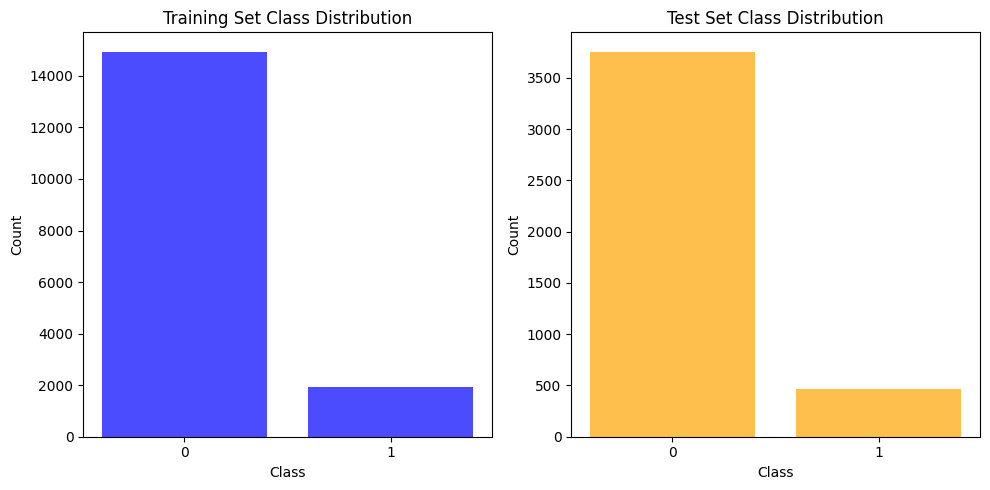

In [25]:
# Check class distribution in training and test sets
train_class_distribution = np.unique(y_train, return_counts=True)
test_class_distribution = np.unique(y_test, return_counts=True)

print("Training Set Class Distribution:")
for label, count in zip(train_class_distribution[0], train_class_distribution[1]):
    print(f"Class {label}: {count} samples")

print("\nTest Set Class Distribution:")
for label, count in zip(test_class_distribution[0], test_class_distribution[1]):
    print(f"Class {label}: {count} samples")

# Visualize the class distribution
plt.figure(figsize=(10, 5))

# Training set
plt.subplot(1, 2, 1)
plt.bar(train_class_distribution[0], train_class_distribution[1], color='blue', alpha=0.7)
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(train_class_distribution[0])

# Test set
plt.subplot(1, 2, 2)
plt.bar(test_class_distribution[0], test_class_distribution[1], color='orange', alpha=0.7)
plt.title("Test Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(test_class_distribution[0])

plt.tight_layout()
plt.show()

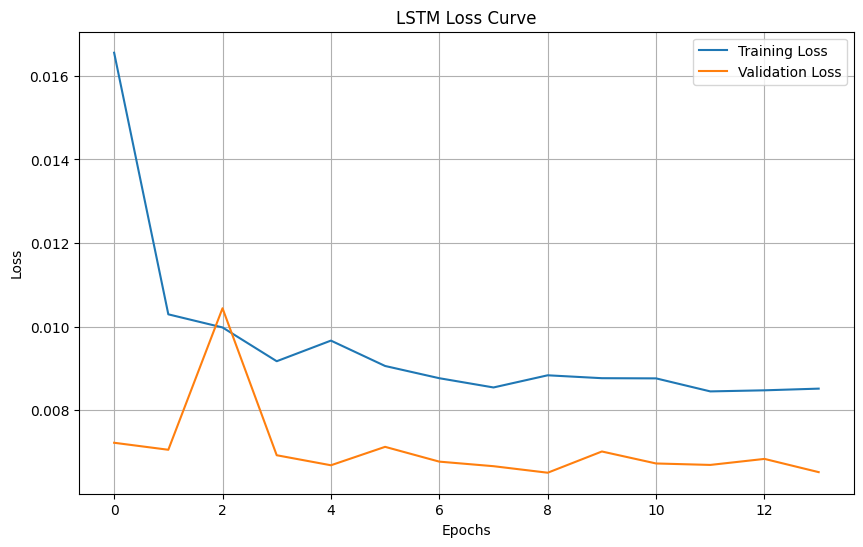

In [26]:
# Assuming `history` is the variable storing the training history from model.fit()
plt.figure(figsize=(10, 6))
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Predict on test set
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.35).astype(int)

# Group by indicator and calculate stats
from collections import defaultdict

indicator_stats = defaultdict(lambda: {'true': [], 'pred': [], 'prob': []})
for i, ind in enumerate(ind_test):
    indicator_stats[ind]['true'].append(y_test[i])
    indicator_stats[ind]['pred'].append(y_pred[i])
    indicator_stats[ind]['prob'].append(y_pred_prob[i])

# Build summary
summary = []
for ind, vals in indicator_stats.items():
    acc = np.mean(np.array(vals['true']) == np.array(vals['pred']))
    avg_prob = np.mean(vals['prob'])
    date = data[data['indicator'] == ind]['date'].values[0] if ind in data['indicator'].values else np.nan
    summary.append({
        'indicator': ind,
        'accuracy': round(acc, 3),
        'avg_predicted_probability': round(avg_prob, 3),
        'samples': len(vals['true']),
        'seen': test_data[test_data['indicator'] == ind]['seen'].values[0]
    })

results_df = pd.DataFrame(summary).sort_values(by='avg_predicted_probability', ascending=False)
results_df.head(500)


132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


,indicator,accuracy,avg_predicted_probability,samples,seen
192,34.160.111.145,0.765,0.838,17,1
159,185.230.63.171,0.720,0.815,25,0
82,162.142.125.242,0.900,0.800,20,0
123,162.142.125.255,0.926,0.796,27,1
10,172.240.108.68,0.800,0.790,25,0
...,...,...,...,...,...
11,185.220.101.149,1.000,0.018,16,0
155,31.31.196.208,1.000,0.015,20,0
176,international.standardbank.com/,1.000,0.014,25,0
67,149.88.27.231,0.962,0.013,26,0


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9059
Precision: 0.6120
Recall: 0.3944
F1 Score: 0.4797


In [29]:
# Extract the indicators from both dataframes
results_indicators = set(results_df['indicator'])
test_data_indicators = set(test_data['indicator'])

# Find matching indicators
matching_indicators = results_indicators.intersection(test_data_indicators)

# Find missing indicators in test_data
missing_in_test_data = results_indicators.difference(test_data_indicators)

# Find missing indicators in sorted_results_df
missing_in_sorted_results = test_data_indicators.difference(results_indicators)

# Display the results
print("Matching Indicators:", matching_indicators)
print("Indicators in results_df but missing in test_data:", missing_in_test_data)
print("Indicators in test_data but missing in results_df:", missing_in_sorted_results)

Matching Indicators: {'156.146.63.176', '162.142.125.242', '156.146.63.174', '23.26.221.8', '46.246.8.46', '156.146.63.175', '46.246.8.56', '3.14.182.203', '104.21.48.1', '156.146.63.177', '45.142.193.66', '102.129.153.71', '190.92.174.36', '156.146.63.167', '104.18.32.191', '64.64.112.131', '156.146.63.170', '208.87.233.190', '46.246.8.136', '46.246.8.43', '23.26.221.25', '185.38.109.109', '62.173.38.206', '102.129.153.158', '162.241.248.14', '192.124.249.112', '74.119.239.234', '185.253.162.21', '64.64.112.158', '207.244.89.161', 'international.standardbank.com/', '45.142.193.149', '156.146.63.166', '45.142.193.183', '104.21.3.76', '46.246.8.122', '23.26.221.21', '172.240.108.68', '216.218.130.2', '46.246.8.101', '64.64.112.145', '47.237.115.193', '64.64.112.146', '20.48.204.4', '45.142.193.141', '46.246.8.144', '107.180.119.251', '15.235.218.150', '162.241.225.237', '46.246.8.91', '23.26.221.10', '212.102.35.18', '156.146.63.181', '34.160.111.145', 'geo.netsupportsoftware.com/locati

In [30]:

# Filter the matching indicators from results_df
matching_indicators_data = results_df[results_df['indicator'].isin(data['indicator'])]

# Get the list of indicators from matching_indicators_data
matching_indicators = matching_indicators_data['indicator'].unique()

# Filter the last 90 days of data for these indicators where seen = 1
ninety_days_ago = datetime.now() - timedelta(days=90)
seen_in_last_90_days = data[
    (data['indicator'].isin(matching_indicators)) & 
    (data['seen'] == 1) & 
    (data['date'] >= ninety_days_ago)
]

# Get the list of indicators that have been seen
seen_indicators = seen_in_last_90_days['indicator'].unique()

# Find indicators that have not been seen in the last 90 days
not_seen_indicators = set(matching_indicators) - set(seen_indicators)

# Display the indicators not seen in the last 90 days
if not_seen_indicators:
    print("The following indicators have NOT been seen in the last 90 days:")
    print(not_seen_indicators)
else:
    print("All matching indicators have been seen in the last 90 days.")

# Exclude not_seen_indicators from the display list
display_indicators = set(matching_indicators) - not_seen_indicators

# Display the results
matching_indicators_data[matching_indicators_data['indicator'].isin(display_indicators)][['indicator', 'avg_predicted_probability']]

The following indicators have NOT been seen in the last 90 days:
{'208.87.233.190', '185.220.101.149', '146.70.57.34', '31.31.196.208', '146.70.204.179', '67.225.140.4', '149.88.27.231', 'international.standardbank.com/'}


,indicator,avg_predicted_probability
192,34.160.111.145,0.838
159,185.230.63.171,0.815
82,162.142.125.242,0.800
123,162.142.125.255,0.796
10,172.240.108.68,0.790
...,...,...
1,70.39.115.74,0.020
13,20.48.204.4,0.020
72,173.208.96.45,0.020
191,176.113.74.89,0.020


In [32]:
# Add a column to indicate whether the prediction was "Right" or "Wrong"
matching_indicators_data.loc[:, 'prediction_status'] = matching_indicators_data.apply(
    lambda row: 'Right' if (row['avg_predicted_probability'] >= 0.5 and row['seen'] == 1) or
                              (row['avg_predicted_probability'] < 0.5 and row['seen'] == 0)
                else 'Wrong',
    axis=1
)

# Identify false negatives: indicators in matching_indicators_data but below the threshold
false_negatives = results_df[
    (results_df['indicator'].isin(matching_indicators_data['indicator'])) & 
    (results_df['avg_predicted_probability'] < 0.5) &  # Below the threshold for being seen
    (results_df['seen'] == 1) &  # Actual value is seen
    (~results_df['indicator'].isin(not_seen_indicators))
].copy()

if not false_negatives.empty:
    false_negatives.loc[:, 'prediction_status'] = 'False Negative'

# Identify false positives: indicators not in matching_indicators_data but meet the threshold
false_positives = results_df[
    (results_df['avg_predicted_probability'] >= 0.5) &  # Above the threshold for being seen
    (results_df['seen'] == 0) &  # Actual value is not seen
    (~results_df['indicator'].isin(not_seen_indicators))
].copy()

if not false_positives.empty:
    false_positives.loc[:, 'prediction_status'] = 'False Positive'

# Combine all results
combined_results = pd.concat([matching_indicators_data, false_negatives, false_positives])

# Resolve duplicate indicators by prioritizing "False Negative" and "False Positive" over "Wrong"
final_results = (
    combined_results.sort_values(by='prediction_status', key=lambda col: col.map({'False Negative': 1, 'False Positive': 2, 'Wrong': 3, 'Right': 4}))
    .drop_duplicates(subset='indicator', keep='first')
)

# Display the final results
final_results[['indicator', 'avg_predicted_probability', 'seen', 'prediction_status']]

,indicator,avg_predicted_probability,seen,prediction_status
63,146.71.50.198,0.417,1,False Negative
29,64.64.112.145,0.295,1,False Negative
61,84.239.31.15,0.364,1,False Negative
87,46.246.8.73,0.155,1,False Negative
2,68.67.179.164,0.129,1,False Negative
...,...,...,...,...
155,31.31.196.208,0.015,0,Right
72,173.208.96.45,0.020,0,Right
94,146.70.57.34,0.011,0,Right
191,176.113.74.89,0.020,0,Right


In [33]:
# Extract rows where prediction_status is either "False Negative" or "False Positive"
false_negatives_and_positives = final_results[
    final_results['prediction_status'].isin(['False Negative', 'False Positive'])
].copy()

# Display the extracted rows
false_negatives_and_positives

,indicator,accuracy,avg_predicted_probability,samples,seen,prediction_status
63,146.71.50.198,0.550,0.417,20,1,False Negative
29,64.64.112.145,0.696,0.295,23,1,False Negative
61,84.239.31.15,0.571,0.364,21,1,False Negative
87,46.246.8.73,0.962,0.155,26,1,False Negative
2,68.67.179.164,1.000,0.129,18,1,False Negative
82,162.142.125.242,0.900,0.800,20,0,False Positive
10,172.240.108.68,0.800,0.790,25,0,False Positive
159,185.230.63.171,0.720,0.815,25,0,False Positive
73,104.21.61.32,0.368,0.613,19,0,False Positive
170,www.shorturl.at/,0.440,0.547,25,0,False Positive


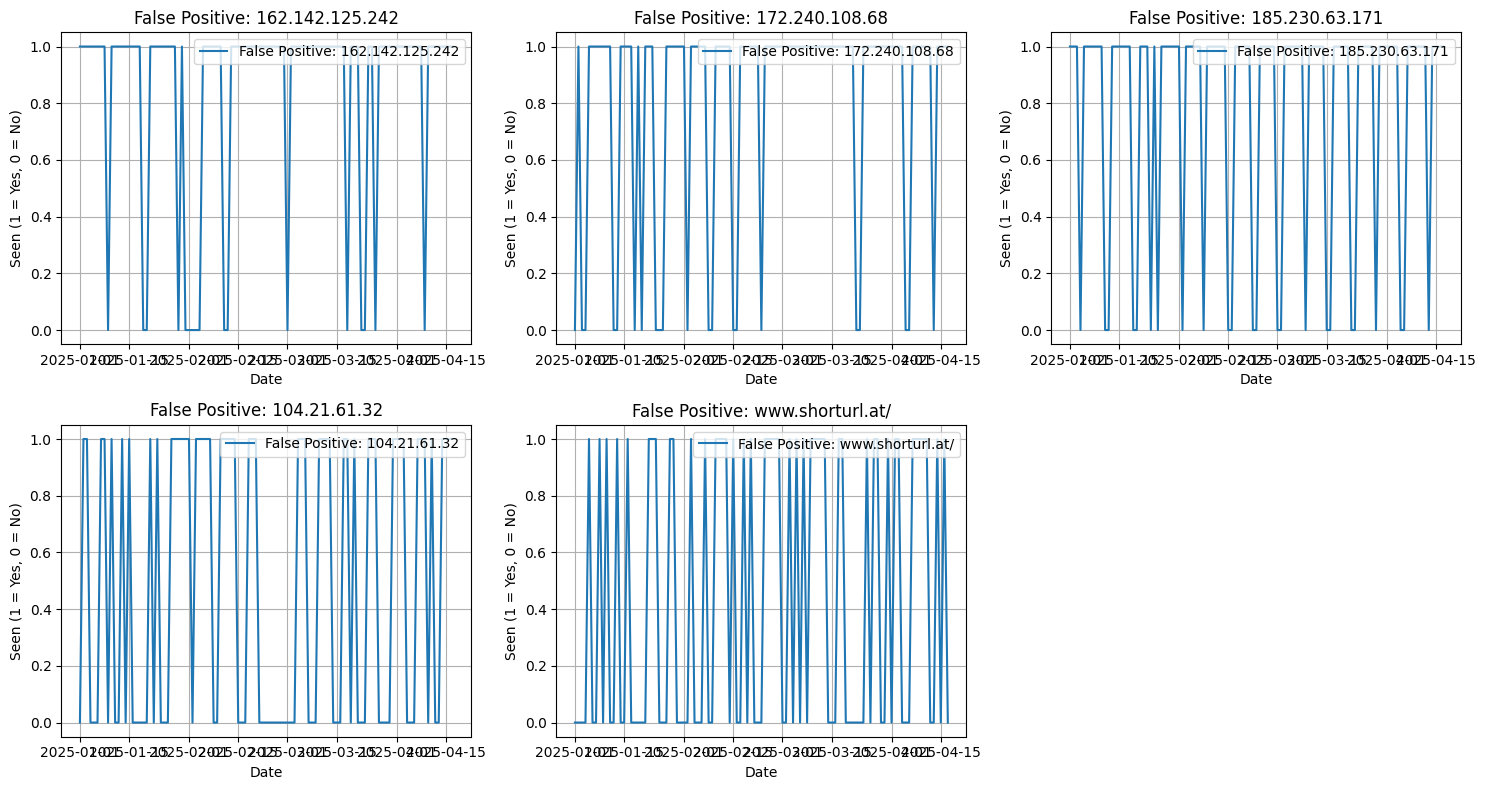

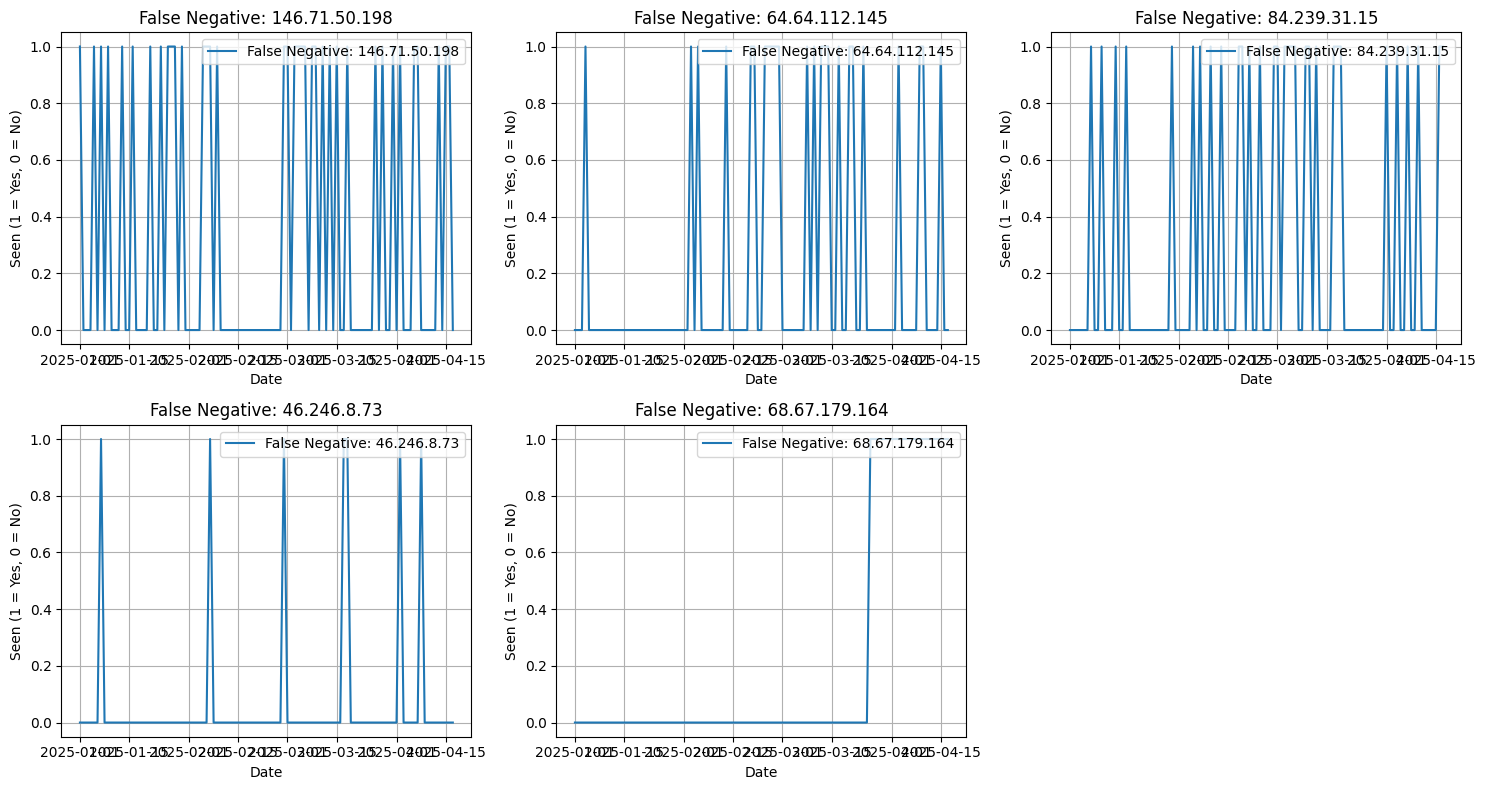

In [34]:
import matplotlib.pyplot as plt
import math

# Separate false positives and false negatives
false_positives = false_negatives_and_positives[
    false_negatives_and_positives['prediction_status'] == 'False Positive'
]

false_negatives = false_negatives_and_positives[
    false_negatives_and_positives['prediction_status'] == 'False Negative'
]

# Merge false positives and false negatives with modelData to get historical activity
false_positive_activity = modelData[modelData['indicator'].isin(false_positives['indicator'])]
false_negative_activity = modelData[modelData['indicator'].isin(false_negatives['indicator'])]

# Function to plot indicators in a grid
def plot_indicators_in_grid(activity_data, indicators, title_prefix):
    num_indicators = len(indicators)
    cols = 3  # Number of columns in the grid
    rows = math.ceil(num_indicators / cols)  # Calculate rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for i, indicator in enumerate(indicators):
        ax = axes[i]
        indicator_data = activity_data[activity_data['indicator'] == indicator]
        ax.plot(indicator_data['date'], indicator_data['seen'], label=f'{title_prefix}: {indicator}')
        ax.set_title(f'{title_prefix}: {indicator}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Seen (1 = Yes, 0 = No)')
        ax.legend(loc='upper right')
        ax.grid(True)

    # Hide any unused subplots
    for i in range(len(indicators), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Plot false positives in a grid
plot_indicators_in_grid(false_positive_activity, false_positives['indicator'].unique(), 'False Positive')

# Plot false negatives in a grid
plot_indicators_in_grid(false_negative_activity, false_negatives['indicator'].unique(), 'False Negative')

In [ ]:
days_since_last_seen = modelData['days_since_last_seen']

days_since_last_seen = test_data.groupby('indicator').agg({
    'days_since_last_seen': ['mean', 'max']
}).reset_index()

# Rename columns for clarity
days_since_last_seen.columns = ['indicator', 'mean_days_since_last_seen', 'max_days_since_last_seen']

days_since_last_seen

,indicator,mean_days_since_last_seen,max_days_since_last_seen
0,102.129.153.158,27.0,27
1,102.129.153.43,51.0,51
2,102.129.153.71,7.0,7
3,102.165.16.161,14.0,14
4,104.160.6.2,1.0,1
...,...,...,...
196,international.standardbank.com/,93.0,93
197,pub.marq.com/,14.0,14
198,realinvestmentadvice.com/,1.0,1
199,www.emergencylighting.com/,71.0,71


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bandit threshold options
actions = [0.4, 0.5, 0.6, 0.7]
epsilon = 0.1  # 10% exploration

# Per-indicator bandit state
bandits = {}

# Logging
reward_log = []
threshold_log = []
actual_outcomes = []

# ✅ Warm-start bandit with historical LSTM accuracy
def choose_action(indicator):
    if indicator not in bandits:
        historical_info = results_df[results_df['indicator'] == indicator]
        if not historical_info.empty:
            global_accuracy_for_indicator = historical_info['accuracy'].values[0]
        else:
            global_accuracy_for_indicator = 0.5  # neutral default

        initial_reward = global_accuracy_for_indicator * 10
        bandits[indicator] = {
            'rewards': np.array([initial_reward] * len(actions)),
            'counts': np.array([10] * len(actions))
        }

    rewards = bandits[indicator]['rewards']
    counts = bandits[indicator]['counts']

    if np.random.rand() < epsilon:
        return np.random.choice(len(actions))  # explore
    else:
        return np.argmax(rewards / (counts + 1e-5))  # exploit

# ✅ Update reward
def update_rewards(indicator, action, reward):
    bandits[indicator]['counts'][action] += 1
    bandits[indicator]['rewards'][action] += reward

# Process false_negatives_and_positives through Bandit Evaluation
for _, row in false_negatives_and_positives.iterrows():
    indicator = row['indicator']
    prob = row['avg_predicted_probability']
    days_since_last_seen = row['days_since_last_seen']
    action = choose_action(indicator)
    threshold = actions[action]

    # Predict
    prediction = 1 if prob > threshold else 0

    # Lookup actual
    actual = row['seen']  # Use the 'seen' column from false_negatives_and_positives

    # Calculate reward
    reward = 1 if prediction == actual else 0
    update_rewards(indicator, action, reward)

    # Log results
    reward_log.append(reward)
    threshold_log.append(threshold)
    actual_outcomes.append({
        'indicator': indicator,
        'predicted_prob': prob,
        'threshold': threshold,
        'predicted': prediction,
        'actual': actual,
        'reward': reward
    })

# ✅ Optional Stats & Plots
print("\n=== Aggregated Threshold Usage Across All Indicators ===")
aggregated_counts = np.zeros(len(actions))
aggregated_rewards = np.zeros(len(actions))

for bandit in bandits.values():
    aggregated_counts += bandit['counts']
    aggregated_rewards += bandit['rewards']

avg_rewards = aggregated_rewards / (aggregated_counts + 1e-5)
for a, r, c in zip(actions, avg_rewards, aggregated_counts):
    print(f"Threshold {a}: avg_reward={r:.3f}, used {int(c)}x")

# 🎯 Plot cumulative reward
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(reward_log))
plt.title("🎯 Cumulative Reward Over Time")
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.grid(True)
plt.show()

# 🧠 Plot threshold usage
plt.figure(figsize=(8, 4))
plt.hist(threshold_log, bins=len(actions), rwidth=0.8)
plt.title("🧠 Thresholds Chosen Across All Indicators")
plt.xlabel("Threshold")
plt.ylabel("Times Selected")
plt.grid(True)
plt.show()

KeyError: 'days_since_last_seen'

In [ ]:
bandit_results_df = pd.DataFrame(actual_outcomes)
# Step 2: Group and summarize per indicator
results_summary = bandit_results_df.groupby("indicator").agg(
    total_predictions=('predicted', 'count'),
    times_predicted_seen=('predicted', 'sum'),
    times_actually_seen=('actual', 'sum'),
    correct_predictions=('reward', 'sum'),
    accuracy=('reward', 'mean'),
    avg_predicted_prob=('predicted_prob', 'mean'),
    avg_threshold=('threshold', 'mean'),
).reset_index().sort_values(by='accuracy', ascending=False)

# Step 3: Preview the summary
results_summary


,indicator,total_predictions,times_predicted_seen,times_actually_seen,correct_predictions,accuracy,avg_predicted_prob,avg_threshold
5,www.shorturl.at/,1,1,1,1,1.0,0.438,0.4
0,172.240.108.68,1,1,0,0,0.0,0.847,0.4
1,185.230.63.171,1,1,0,0,0.0,0.833,0.4
2,192.124.249.112,1,0,1,0,0.0,0.021,0.4
3,34.160.111.145,1,1,0,0,0.0,0.884,0.4
4,68.67.179.164,1,0,1,0,0.0,0.148,0.4


In [ ]:
best_thresholds = {
    ind: actions[np.argmax(data['rewards'] / (data['counts'] + 1e-5))]
    for ind, data in bandits.items()
}

for _, row in false_negatives_and_positives.iterrows():
    indicator = row['indicator']
    prob = row['avg_predicted_probability']
    best_threshold = best_thresholds.get(indicator, 0.5)  # Default to 0.5 if no threshold is found

    # Make prediction using the best threshold
    prediction = 1 if prob > best_threshold else 0

    # Compare with actual value
    actual = row['seen']
    print(f"Indicator: {indicator}, Prediction: {prediction}, Actual: {actual}")

Indicator: www.shorturl.at/, Prediction: 1, Actual: 1
Indicator: 68.67.179.164, Prediction: 0, Actual: 1
Indicator: 192.124.249.112, Prediction: 0, Actual: 1
Indicator: 34.160.111.145, Prediction: 1, Actual: 0
Indicator: 172.240.108.68, Prediction: 1, Actual: 0
Indicator: 185.230.63.171, Prediction: 1, Actual: 0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Train a Random Forest for feature importance analysis
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train.reshape(X_train.shape[0], -1), y_train)

# Compute feature importance
feature_importance = rf.feature_importances_

# Display feature importance
feature_names = df.drop(columns=['label', 'indicator']).columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
21,lag_2ewm_seen_long,0.141660
20,lag_1ewm_seen_long,0.112780
2,activity_score_normalized,0.098445
1,activity_score,0.097297
13,lag_2_ewm_seen,0.093679
12,lag_1_ewm_seen,0.084999
19,lag_2rolling_mean_30,0.078350
18,lag_1rolling_mean_30,0.074776
7,lag_2_dayofweek,0.033103
10,lag_1_days_since_last_seen,0.029902
